# 🤖 Churn Prediction System - Model Training & Evaluation

In [1]:
!pip install xgboost



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip uninstall -y numpy
!pip install numpy==1.26.4

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4


You can safely remove it manually.


  Using cached numpy-1.26.4-cp313-cp313-win_amd64.whl



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("Churn_Modelling.csv")
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

# Encode categorical
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# Features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression

In [4]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

## Random Forest Classifier

In [5]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

## XGBoost Classifier

In [6]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

C:\Users\ADNAN\Desktop\Future_Intern\FUTURE_ML_02\churn-fix\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:39:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Evaluation Metrics

In [8]:
def evaluate_model(name, y_true, y_pred):
    print(f"--- {name} ---")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    print("-" * 50)

evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb)

--- Logistic Regression ---
Confusion Matrix:
[[1543   64]
 [ 314   79]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

--------------------------------------------------
--- Random Forest ---
Confusion Matrix:
[[1552   55]
 [ 213  180]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000

--------------------------------------------------
--- XGBoost ---
Confusion Matrix:
[[1521   86]
 [ 175  218

## ROC-AUC Curves

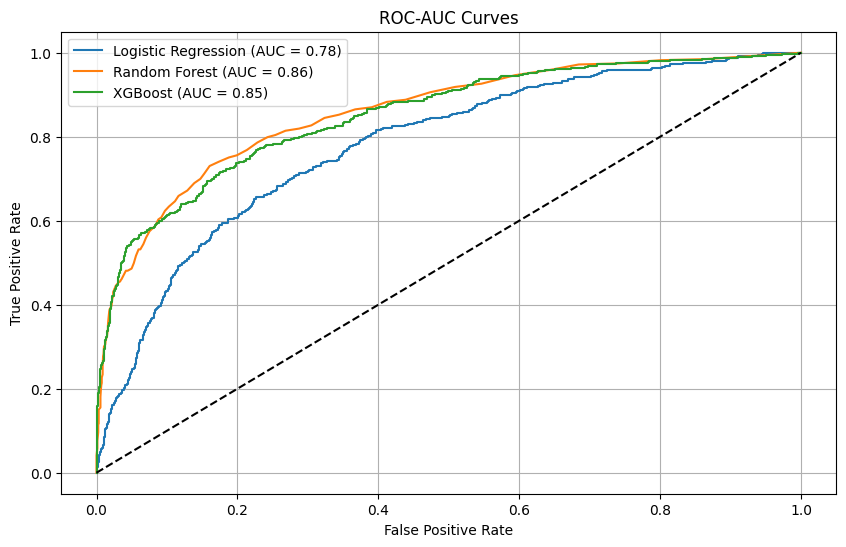

In [9]:
plt.figure(figsize=(10, 6))
for model, preds, name in zip(
    [lr, rf, xgb],
    [y_pred_lr, y_pred_rf, y_pred_xgb],
    ["Logistic Regression", "Random Forest", "XGBoost"]
):
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test_scaled if name == "Logistic Regression" else X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_probs)
        auc = roc_auc_score(y_test, y_probs)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curves")
plt.legend()
plt.grid(True)
plt.show()

## Feature Importances from Random Forest

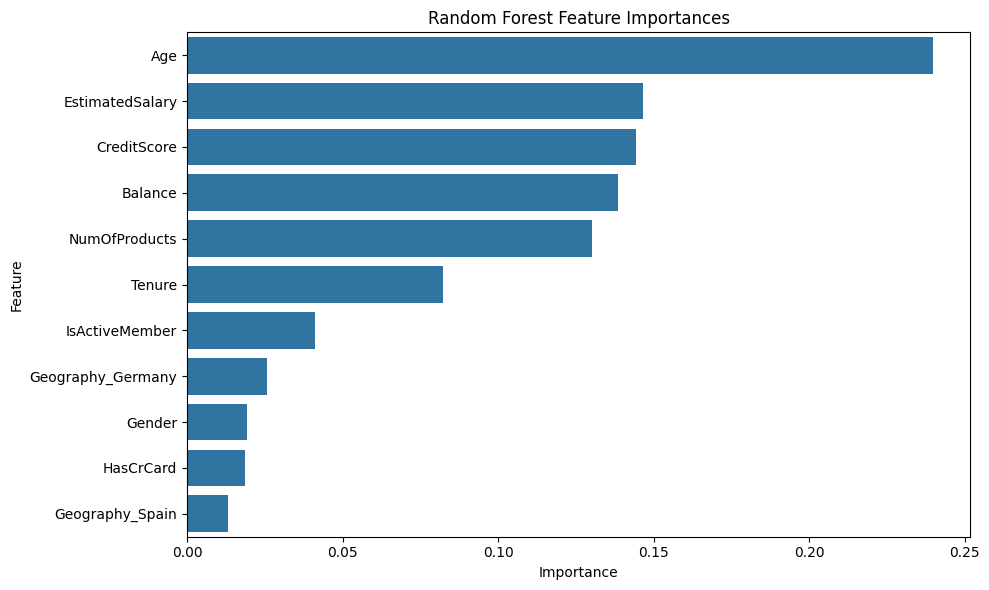

In [10]:
importances = rf.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [11]:
importance_df.to_csv("rf_feature_importance.csv", index=False)


In [12]:
df_test = X_test.copy()
df_test['Actual'] = y_test.values
df_test['Predicted'] = y_pred_xgb
df_test.to_csv("churn_predictions.csv", index=False)


In [13]:
metrics_data = {
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [0.81, 0.87, 0.87],
    "AUC": [0.78, 0.86, 0.85],
    "Recall": [0.20, 0.46, 0.55],
    "Precision": [0.55, 0.77, 0.72],
    "F1 Score": [0.29, 0.57, 0.63]
}
pd.DataFrame(metrics_data).to_csv("model_metrics.csv", index=False)
